### Import library

In [1]:
pip install ttth-mds5-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.8/105.8 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.7 MB/s eta 0:00:00
  Created wheel for ttth-mds5-analyzer: filename=ttth_mds5_analyzer-0.1.11-py3-none-any.whl size=102383 sha256=df195aea2ec6458b62330d40da48d9a9110f8f271b9d85a46212e7c5d2a0c3ad
  Stored in directory: /root/.cache/pip/wheels/6a/fc/a7/b2736e65e87985026a918d988ad0979bbc5372f3d3f13e1d13
Successfully built ttth-mds5-analyzer


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from analysis.analyzer import TTTH_Analyzer

In [3]:
_analyzer = TTTH_Analyzer()

### Read dataset and overview

In [4]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [5]:
df1 = pd.read_csv('/content/gdrive/MyDrive/DL07_K311_HuynhLeXuanAnh_DangDucDuy_NguyenThiTuyetVan/Project 1/data/quan-binh-thanh.csv')
df2 = pd.read_csv('/content/gdrive/MyDrive/DL07_K311_HuynhLeXuanAnh_DangDucDuy_NguyenThiTuyetVan/Project 1/data/quan-go-vap.csv')
df3 = pd.read_csv('/content/gdrive/MyDrive/DL07_K311_HuynhLeXuanAnh_DangDucDuy_NguyenThiTuyetVan/Project 1/data/quan-phu-nhuan.csv')

In [6]:
df1['dia_chi'] = "Quận Bình Thạnh"
df2['dia_chi'] = "Quận Gò Vấp"
df3['dia_chi'] = "Quận Phú Nhuận"

In [7]:
df = pd.concat([df1, df2, df3], axis=0, ignore_index=True)

In [8]:
df.shape

(8273, 23)

In [9]:
df.head()

,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,"3,85 tỷ","106,94 triệu/m²",36 m²,Quận Bình Thạnh,🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,NaN,"Nhà ngõ, hẻm",36 m²,NaN,...,2 phòng,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5 m,8 m,NaN,NaN,"[134.04, 125.8, 125.8, 125.8, 138.64, 138.64, ..."
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...","9,79 tỷ","157,90 triệu/m²",62 m²,Quận Bình Thạnh,"CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...",0909761320,"Nhà ngõ, hẻm",62 m²,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[133.33, 135.54, 130.95, 130.02, 130.02, 136.3..."
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,"7,2 tỷ","133,33 triệu/m²",54 m²,Quận Bình Thạnh,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,0909983786,"Nhà ngõ, hẻm",54 m²,NaN,...,2 phòng,2.0,Hoàn thiện cơ bản,NaN,Hẻm xe hơi,7 m,7.7 m,NaN,NaN,"[168.37, 168.37, 120.71, 120.71, 124.24, 124.5..."
3,🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN XÂY M...,"8,5 tỷ","102,41 triệu/m²",83 m²,Quận Bình Thạnh,#e45\n🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN...,0969415765,"Nhà ngõ, hẻm",83 m²,NaN,...,NaN,NaN,NaN,NaN,NaN,7.5 m,11.5 m,NaN,NaN,"[159.22, 159.22, 157.45, 157.45, 135.08, 122.2..."
4,Nhà hẻm cách đường mặt tiền 20m,"2,85 tỷ","158,33 triệu/m²",18 m²,Quận Bình Thạnh,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,NaN,"Nhà ngõ, hẻm",18 m²,18 m²,...,1 phòng,NaN,NaN,NaN,Hiện trạng khác,3 m,6 m,NaN,NaN,"[132.67, 132.67, 169.64, 169.64, 133.33, 133.3..."


In [10]:
df.tail()

,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia
8268,Nhà hẻm xe hơi dôi đâu,"6,5 tỷ","185,71 triệu/m²",35 m²,Quận Phú Nhuận,"🌹HOÀNG DIỆU—PHU NHUẬN \n🌹GIÁ:6,5 TỶ \n🌹BÁN NHÀ...",090803 ***,"Nhà ngõ, hẻm",35 m²,140 m²,...,3 phòng,2.0,Hoàn thiện cơ bản,Đông,NaN,7 m,5 m,NaN,NaN,"[190, 190, 181.82, 186.88, 186.88, 187.8, 205...."
8269,🔥CHÍNH CHỦ - GIÁ SIÊU TỐT MẶT TIỀN PHÚ NHUẬN (...,"29,9 tỷ","498,33 triệu/m²",60 m²,Quận Phú Nhuận,🌟 Vị trí đắc địa:\nNgay siêu thị Co.op Mart\nG...,090572 ***,"Nhà mặt phố, mặt tiền",60 m²,NaN,...,4 phòng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[261.9, 262.5, 226.19, 226.19, 235, 296.47, 29..."
8270,"Bán gấp nhà mặt phố Đường Phan Xích Long, Phườ...","14,8 tỷ","294,82 triệu/m²",50.2 m²,Quận Phú Nhuận,"Nhà mặt phố tại Đường Phan Xích Long, Phường 2...",NaN,"Nhà mặt phố, mặt tiền",50.2 m²,21.2 m²,...,1 phòng,3.0,Bàn giao thô,Đông Bắc,NaN,8.2 m,3 m,NaN,NaN,[]
8271,NHÀ BÁN TRUNG TÂM PHÚ NHUẬN HẺM XE HƠI,"10,5 tỷ","184,21 triệu/m²",57 m²,Quận Phú Nhuận,Diện tích: 3.8m x 15m nở hậu nhẹ • Trệt 2 lầu ...,039792 ***,"Nhà ngõ, hẻm",57 m²,228 m²,...,5 phòng,4.0,Nội thất đầy đủ,Đông Nam,Hẻm xe hơi,3.8 m,15 m,NaN,NaN,[]
8272,"SIÊU VIP, NHÀ MẶT TIỀN 5M. ĐƯỜNG HOA HUỆ-PHÚ N...","5,32 tỷ","106,40 triệu/m²",50 m²,Quận Phú Nhuận,"Mặt tiền ngang 5m đẹp, kế căn góc 2 MT, hiểm c...",079227 ***,"Nhà ngõ, hẻm",50 m²,50 m²,...,4 phòng,NaN,NaN,NaN,Hẻm xe hơi,5 m,10 m,NaN,NaN,"[149.65, 161.06, 161.06, 145.83, 161.82, 143.4..."


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tieu_de              7964 non-null   object 
 1   gia_ban              7961 non-null   object 
 2   don_gia              7961 non-null   object 
 3   dien_tich            7961 non-null   object 
 4   dia_chi              8273 non-null   object 
 5   mo_ta                7961 non-null   object 
 6   dien_thoai           3959 non-null   object 
 7   loai_hinh            7961 non-null   object 
 8   dien_tich_dat        7961 non-null   object 
 9   dien_tich_su_dung    3754 non-null   object 
 10  gia_m2               7961 non-null   object 
 11  giay_to_phap_ly      7460 non-null   object 
 12  so_phong_ngu         7961 non-null   object 
 13  so_phong_ve_sinh     5977 non-null   object 
 14  tong_so_tang         5501 non-null   float64
 15  tinh_trang_noi_that  4432 non-null   o

In [12]:
df.describe()

,tong_so_tang
count,5501.000000
mean,3.073078
std,1.597647
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,44.000000


In [13]:
df.describe(include='O')

,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,so_phong_ngu,so_phong_ve_sinh,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia
count,7964,7961,7961,7961,8273,7961,3959,7961,7961,3754,...,7961,5977,4432,1321,5207,6106,5970,25,25,8273
unique,7908,811,3425,651,3,7917,1424,4,651,595,...,11,7,4,8,8,210,239,24,17,258
top,BÁN GẤP TRONG THÁNG - Bán nhà Nguyễn Cửu Vân 3...,"7,5 tỷ",100 triệu/m²,40 m²,Quận Gò Vấp,"📍 Vị trí trung tâm trên đường Nguyễn Cửu Vân, ...",098460 ***,"Nhà ngõ, hẻm",40 m²,60 m²,...,3 phòng,2 phòng,Nội thất đầy đủ,Đông Nam,Hẻm xe hơi,4 m,10 m,1,A,[]
freq,4,160,85,367,4374,4,48,6701,367,123,...,2248,1925,1820,280,4181,1788,564,2,9,1294


In [14]:
df.isnull().sum()

,0
tieu_de,309
gia_ban,312
don_gia,312
dien_tich,312
dia_chi,0
mo_ta,312
dien_thoai,4314
loai_hinh,312
dien_tich_dat,312
dien_tich_su_dung,4519


##### **Nhận xét:**
*   Có các cột mang giá trị số nhưng do kèm theo đơn vị đo nên cột lại mang kiểu dữ liệu chuỗi --> cần strip đơn vị đo
*   Cần loại các cột chỉ mang dữ liệu chuỗi đã được mô tả trong các cột khác như tieu_de, mo_ta và các cột không cần thiết như don_gia, gia_m2, dien_thoai, dien_tich_su_dung, dien_tich_dat, bieu_do_gia
*   Cần encode cho các cột mang kiểu dữ liệu chuỗi có thể sử dụng như dia_chi, loai_hinh, dac_diem, giay_to_phap_ly, tinh_trang_noi_that
*   Cần xóa các cột mang nhiều giá trị null vì không thể sử dụng



### Preprocessing data

#### Strip unit word and numericalize data

In [15]:
def convert_price(x):
    if pd.isna(x):
        return None
    x = str(x).lower().strip()
    x = x.replace(",",".")
    if "tỷ" in x:
        return float(x.replace("tỷ", "").strip())
    if "triệu" in x:
        return float(x.replace("triệu", "").strip()) / 1000
    return None

df["gia_ban"] = df["gia_ban"].apply(convert_price)

In [16]:
def convert_room(x):
    if pd.isna(x):
        return None
    x = str(x).lower().strip()
    if "nhiều hơn" in x:
        return float(x.replace("nhiều hơn", "").strip().replace("phòng", ""))
    else:
        return float(x.replace("phòng", "").strip())
    return None

df['so_phong_ngu'] = df['so_phong_ngu'].apply(convert_room)
df['so_phong_ve_sinh'] = df['so_phong_ve_sinh'].apply(convert_room)

In [17]:
df["dien_tich"] = df["dien_tich"].astype(str).str.replace("m²","").str.strip().astype(float)
df["chieu_ngang"] = df["chieu_ngang"].astype(str).str.replace("m","").str.strip().astype(float)
df["chieu_dai"] = df["chieu_dai"].astype(str).str.replace("m","").str.strip().astype(float)

#### Drop unnecessary columns

In [18]:
df.drop(columns=['tieu_de', 'mo_ta', 'don_gia', 'gia_m2', 'dien_thoai', 'dien_tich_su_dung', 'dien_tich_dat', 'bieu_do_gia'], inplace=True)

In [19]:
df.columns

Index(['gia_ban', 'dien_tich', 'dia_chi', 'loai_hinh', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem', 'chieu_ngang',
       'chieu_dai', 'ma_can', 'ten_phan_khu_lo'],
      dtype='object')

#### Handle missing values

In [20]:
(df.isna().mean() * 100).sort_values(ascending=False)

,0
ma_can,99.697812
ten_phan_khu_lo,99.697812
huong_cua_chinh,84.032395
tinh_trang_noi_that,46.428140
dac_diem,37.060317
tong_so_tang,33.506588
chieu_dai,27.837544
so_phong_ve_sinh,27.752931
chieu_ngang,26.193642
giay_to_phap_ly,9.827149


In [21]:
# Drop các cột có tỷ lệ missing values >= 50%
df.drop(columns=['ma_can', 'ten_phan_khu_lo', 'huong_cua_chinh'], inplace=True)

In [22]:
df.columns

Index(['gia_ban', 'dien_tich', 'dia_chi', 'loai_hinh', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'dac_diem', 'chieu_ngang', 'chieu_dai'],
      dtype='object')

In [23]:
(df.isna().mean() * 100).sort_values(ascending=False)

,0
tinh_trang_noi_that,46.428140
dac_diem,37.060317
tong_so_tang,33.506588
chieu_dai,27.837544
so_phong_ve_sinh,27.752931
chieu_ngang,26.193642
giay_to_phap_ly,9.827149
gia_ban,3.771304
dien_tich,3.771304
loai_hinh,3.771304


##### **Nhận xét**:
*   Đối với cột có kiểu dữ liệu chuỗi --> Điền 'không rõ'
*   Đối với cột có kiểu dữ liệu số --> Điền median



In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gia_ban              7961 non-null   float64
 1   dien_tich            7961 non-null   float64
 2   dia_chi              8273 non-null   object 
 3   loai_hinh            7961 non-null   object 
 4   giay_to_phap_ly      7460 non-null   object 
 5   so_phong_ngu         7961 non-null   float64
 6   so_phong_ve_sinh     5977 non-null   float64
 7   tong_so_tang         5501 non-null   float64
 8   tinh_trang_noi_that  4432 non-null   object 
 9   dac_diem             5207 non-null   object 
 10  chieu_ngang          6106 non-null   float64
 11  chieu_dai            5970 non-null   float64
dtypes: float64(7), object(5)
memory usage: 775.7+ KB


In [25]:
cols = ['loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that']
df[cols] = df[cols].fillna("Không rõ")
df['dac_diem'] = df['dac_diem'].fillna("Hiện trạng khác")

In [26]:
df = df.fillna(df.median(numeric_only=True))

In [27]:
(df.isna().mean() * 100).sort_values(ascending=False)

,0
gia_ban,0.0
dien_tich,0.0
dia_chi,0.0
loai_hinh,0.0
giay_to_phap_ly,0.0
so_phong_ngu,0.0
so_phong_ve_sinh,0.0
tong_so_tang,0.0
tinh_trang_noi_that,0.0
dac_diem,0.0


### Identify variables

*   Output variable: `gia_ban`
*   Input variables:
    *   dien_tich
    *   dia_chi
    *   loai_hinh
    *   giay_to_phap_ly
    *   so_phong_ngu
    *   so_phong_ve_sinh
    *   tong_so_tang
    *   tinh_trang_noi_that
    *   dac_diem
    *   chieu_ngang
    *   chieu_dai
    *   bieu_do_gia

In [28]:
df_output = df[['gia_ban']]
df_input = df.drop('gia_ban', axis=1)

#### Split into numeric and category dataframe to analyze

In [29]:
cat_cols = df_input.select_dtypes('O').columns
cat_cols

Index(['dia_chi', 'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
       'dac_diem'],
      dtype='object')

In [30]:
num_cols = df_input.select_dtypes(exclude='O').columns
num_cols

Index(['dien_tich', 'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'chieu_ngang', 'chieu_dai'],
      dtype='object')

In [31]:
for col in num_cols:
    n = df[col].nunique()
    if n > 5:
        print(col, '- unique value:', n)
    else:
        print(col, '-', df[col].unique())

dien_tich - unique value: 651
so_phong_ngu - unique value: 10
so_phong_ve_sinh - unique value: 6
tong_so_tang - unique value: 13
chieu_ngang - unique value: 210
chieu_dai - unique value: 239


In [32]:
for col in cat_cols:
    n = df[col].nunique()
    print(col, '-', df[col].unique())

dia_chi - ['Quận Bình Thạnh' 'Quận Gò Vấp' 'Quận Phú Nhuận']
loai_hinh - ['Nhà ngõ, hẻm' 'Nhà phố liền kề' 'Nhà mặt phố, mặt tiền' 'Nhà biệt thự'
 'Không rõ']
giay_to_phap_ly - ['Đã có sổ' 'Không rõ' 'Đang chờ sổ' 'Sổ chung / công chứng vi bằng'
 'Giấy tờ viết tay' 'Không có sổ']
tinh_trang_noi_that - ['Nội thất đầy đủ' 'Không rõ' 'Hoàn thiện cơ bản' 'Nội thất cao cấp'
 'Bàn giao thô']
dac_diem - ['Nhà nở hậu' 'Hiện trạng khác' 'Hẻm xe hơi' 'Nhà nát'
 'Nhà chưa hoàn công' 'Đất chưa chuyển thổ' 'Nhà tóp hậu'
 'Nhà dính quy hoạch / lộ giới']


### EDA

#### Univariate analysis

In [33]:
# Categorical variable analysis

In [34]:
cat_cols

Index(['dia_chi', 'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
       'dac_diem'],
      dtype='object')

Class count of dia_chi:

dia_chi
Quận Gò Vấp        4374
Quận Bình Thạnh    2665
Quận Phú Nhuận     1234
Name: count, dtype: int64


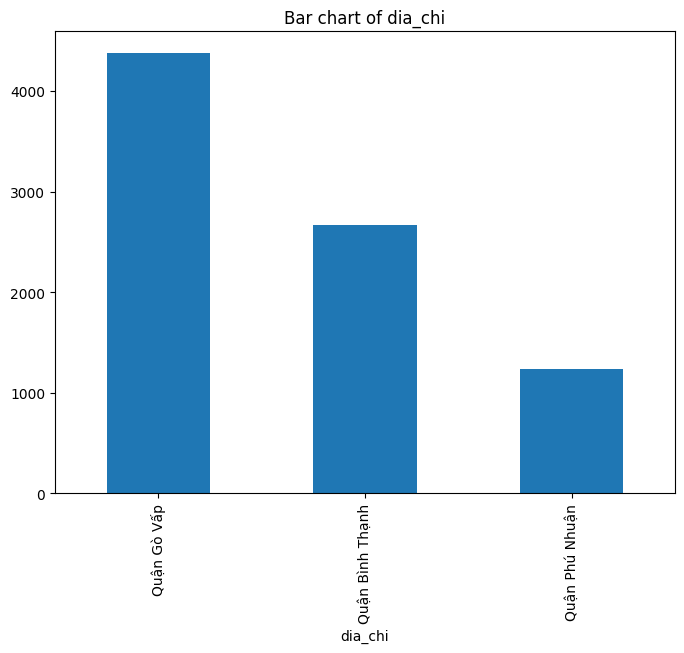

Class count of loai_hinh:

loai_hinh
Nhà ngõ, hẻm             6701
Nhà mặt phố, mặt tiền     926
Không rõ                  312
Nhà phố liền kề           243
Nhà biệt thự               91
Name: count, dtype: int64


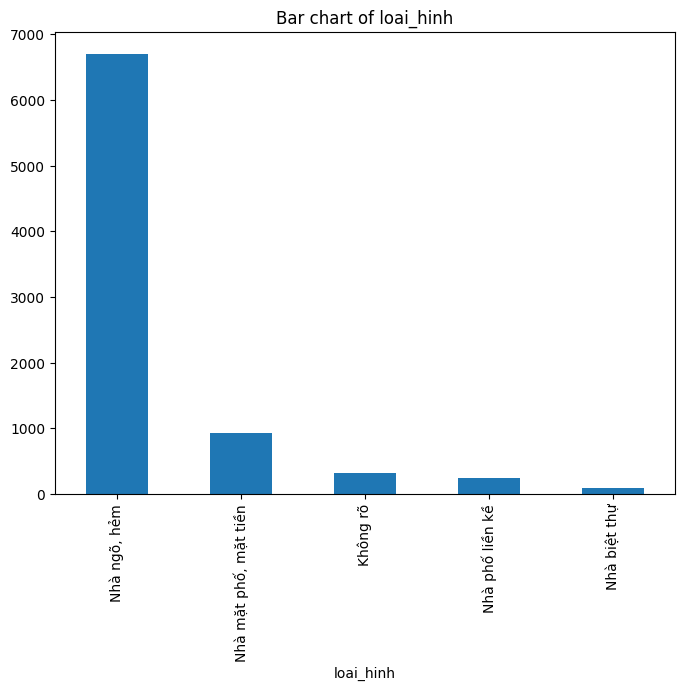

Class count of giay_to_phap_ly:

giay_to_phap_ly
Đã có sổ                         7407
Không rõ                          813
Sổ chung / công chứng vi bằng      22
Đang chờ sổ                        19
Giấy tờ viết tay                    6
Không có sổ                         6
Name: count, dtype: int64


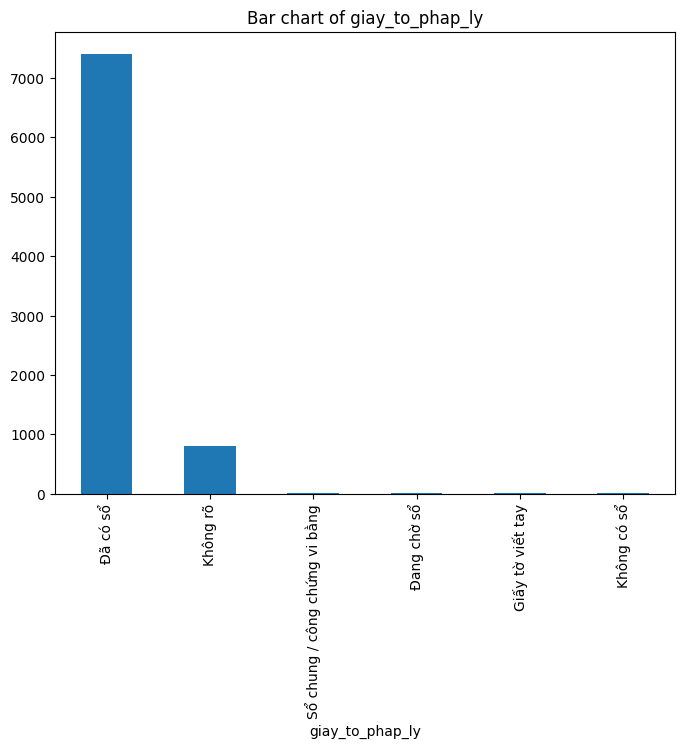

Class count of tinh_trang_noi_that:

tinh_trang_noi_that
Không rõ             3841
Nội thất đầy đủ      1820
Nội thất cao cấp     1740
Hoàn thiện cơ bản     790
Bàn giao thô           82
Name: count, dtype: int64


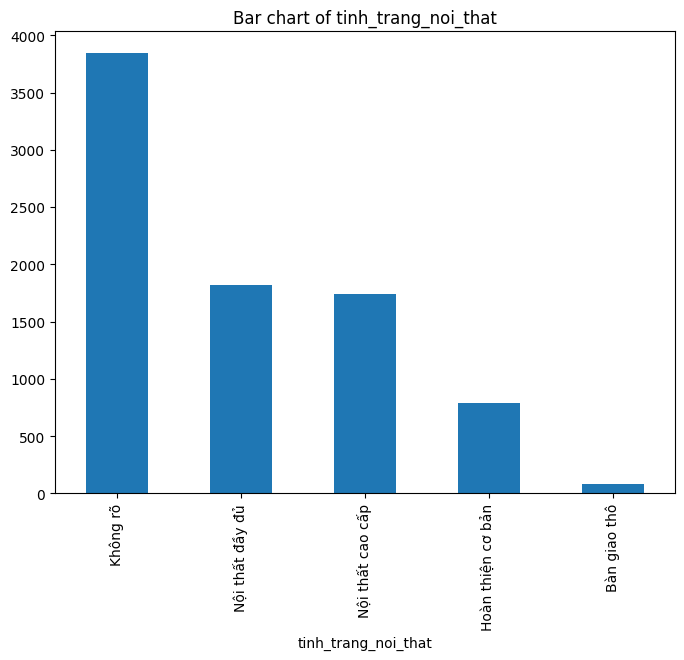

Class count of dac_diem:

dac_diem
Hẻm xe hơi                      4181
Hiện trạng khác                 3189
Nhà nở hậu                       729
Nhà nát                           60
Nhà dính quy hoạch / lộ giới      43
Nhà tóp hậu                       32
Đất chưa chuyển thổ               22
Nhà chưa hoàn công                17
Name: count, dtype: int64


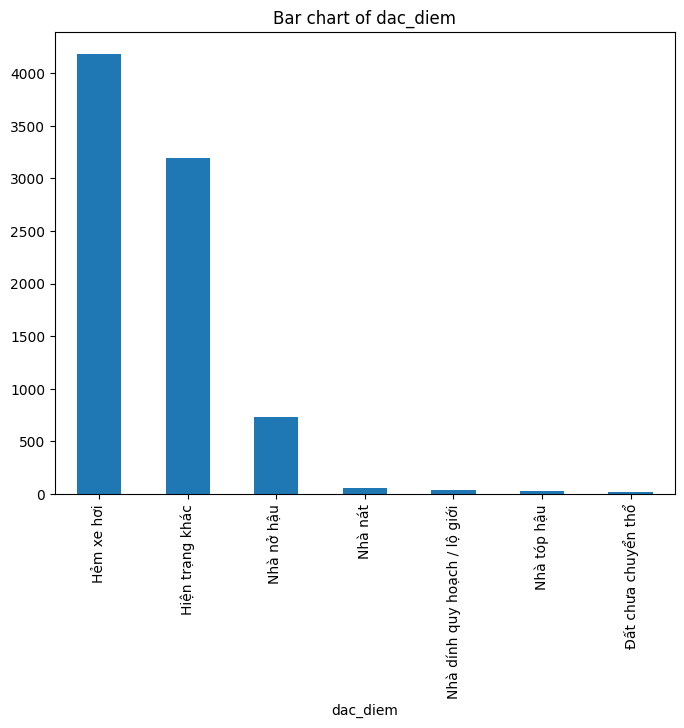

In [35]:
for col in cat_cols:
    _analyzer.analyze_category_variable(col, df_input)

In [36]:
# Numeric variable analysis

In [37]:
num_cols

Index(['dien_tich', 'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'chieu_ngang', 'chieu_dai'],
      dtype='object')

=====
central tendency of dien_tich: {'mean': np.float64(55.623730206696486), 'median': 49.1, 'mode': np.float64(40.0), 'min': 10.0, 'max': 1400.0, 'range': 1390.0}
=====
Dispersion of dien_tich: 
 {'range': 1390.0, 'q1': np.float64(35.0), 'q3': np.float64(65.0), 'iqr': np.float64(30.0), 'var': 1605.736455047111, 'skew': np.float64(9.590956063573568), 'kurtosis': np.float64(225.1992468893097)}
=====


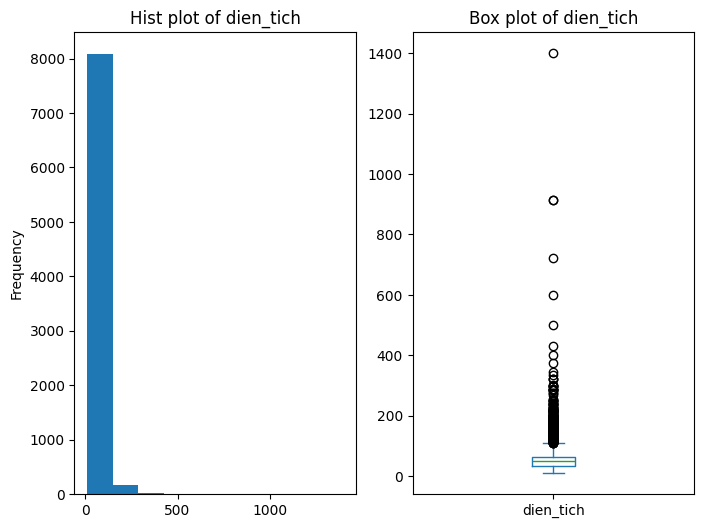

=====
central tendency of so_phong_ngu: {'mean': np.float64(3.5168620814698417), 'median': 3.0, 'mode': np.float64(3.0), 'min': 1.0, 'max': 10.0, 'range': 9.0}
=====
Dispersion of so_phong_ngu: 
 {'range': 9.0, 'q1': np.float64(2.0), 'q3': np.float64(4.0), 'iqr': np.float64(2.0), 'var': 3.1789044656231153, 'skew': np.float64(1.7609245675850296), 'kurtosis': np.float64(3.8240231159531834)}
=====


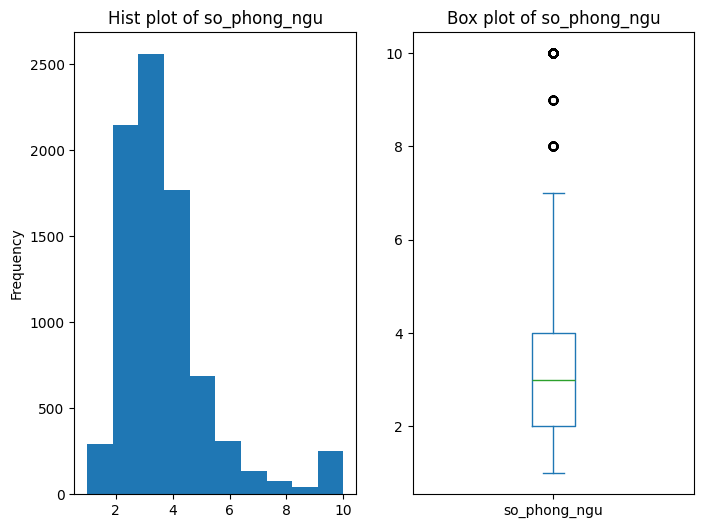

=====
central tendency of so_phong_ve_sinh: {'mean': np.float64(3.251178532575849), 'median': 3.0, 'mode': np.float64(3.0), 'min': 1.0, 'max': 6.0, 'range': 5.0}
=====
Dispersion of so_phong_ve_sinh: 
 {'range': 5.0, 'q1': np.float64(2.0), 'q3': np.float64(4.0), 'iqr': np.float64(2.0), 'var': 1.5377237680497058, 'skew': np.float64(0.8020379947388565), 'kurtosis': np.float64(0.08676890507332713)}
=====


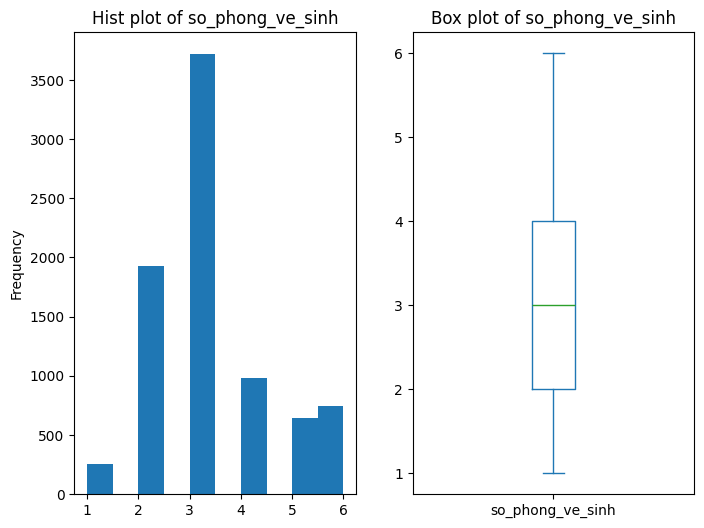

=====
central tendency of tong_so_tang: {'mean': np.float64(3.0485918046657803), 'median': 3.0, 'mode': np.float64(3.0), 'min': 1.0, 'max': 44.0, 'range': 43.0}
=====
Dispersion of tong_so_tang: 
 {'range': 43.0, 'q1': np.float64(2.0), 'q3': np.float64(3.0), 'iqr': np.float64(1.0), 'var': 1.6983155336707048, 'skew': np.float64(10.011723017488032), 'kurtosis': np.float64(240.70994726870438)}
=====


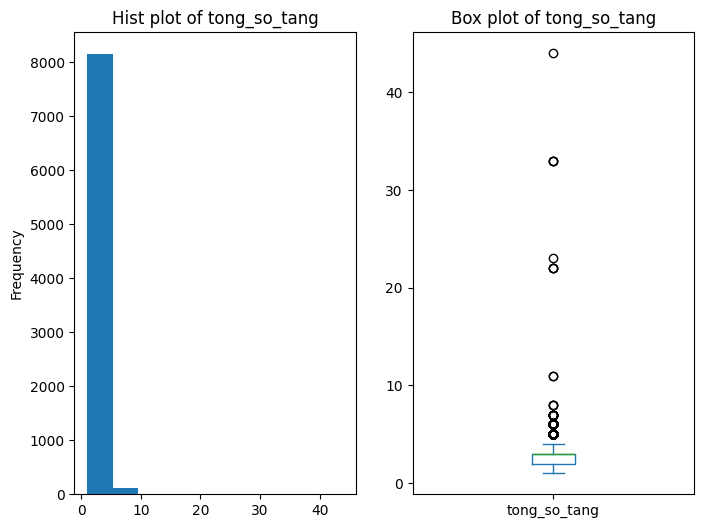

=====
central tendency of chieu_ngang: {'mean': np.float64(4.972246101776864), 'median': 4.0, 'mode': np.float64(4.0), 'min': 2.0, 'max': 4000.0, 'range': 3998.0}
=====
Dispersion of chieu_ngang: 
 {'range': 3998.0, 'q1': np.float64(4.0), 'q3': np.float64(4.5), 'iqr': np.float64(0.5), 'var': 1971.3223027837116, 'skew': np.float64(88.265855613394), 'kurtosis': np.float64(7928.512521954069)}
=====


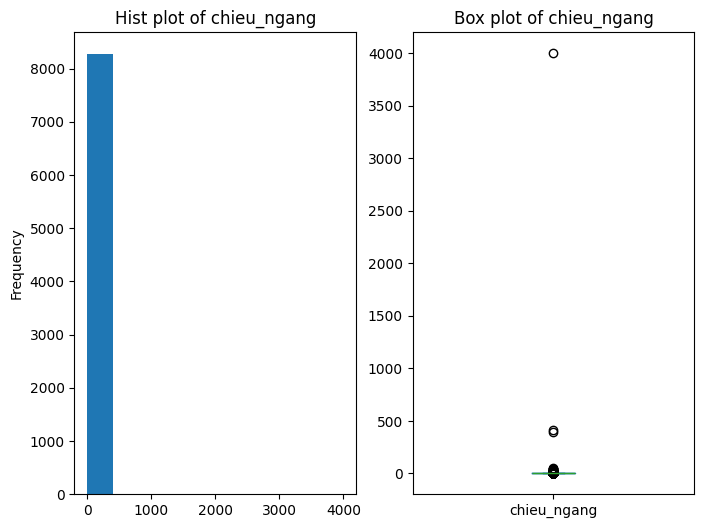

=====
central tendency of chieu_dai: {'mean': np.float64(15.4496990209114), 'median': 12.0, 'mode': np.float64(12.0), 'min': 1.4, 'max': 24000.0, 'range': 23998.6}
=====
Dispersion of chieu_dai: 
 {'range': 23998.6, 'q1': np.float64(10.0), 'q3': np.float64(14.5), 'iqr': np.float64(4.5), 'var': 69572.60144143002, 'skew': np.float64(90.91422629969955), 'kurtosis': np.float64(8267.928425007376)}
=====


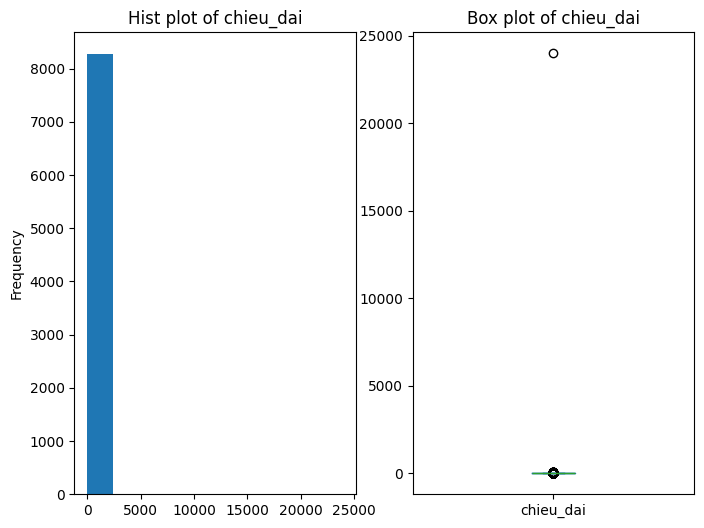

In [38]:
for col in num_cols:
    _analyzer.analyze_numeric_variable(col, df_input)

In [39]:
# Output analysis

=====
central tendency of gia_ban: {'mean': np.float64(8.170688867399976), 'median': 6.7, 'mode': np.float64(6.7), 'min': 0.5, 'max': 535.0, 'range': 534.5}
=====
Dispersion of gia_ban: 
 {'range': 534.5, 'q1': np.float64(4.9), 'q3': np.float64(8.8), 'iqr': np.float64(3.9000000000000004), 'var': 99.0232534725742, 'skew': np.float64(27.713285057361325), 'kurtosis': np.float64(1214.8675805567711)}
=====


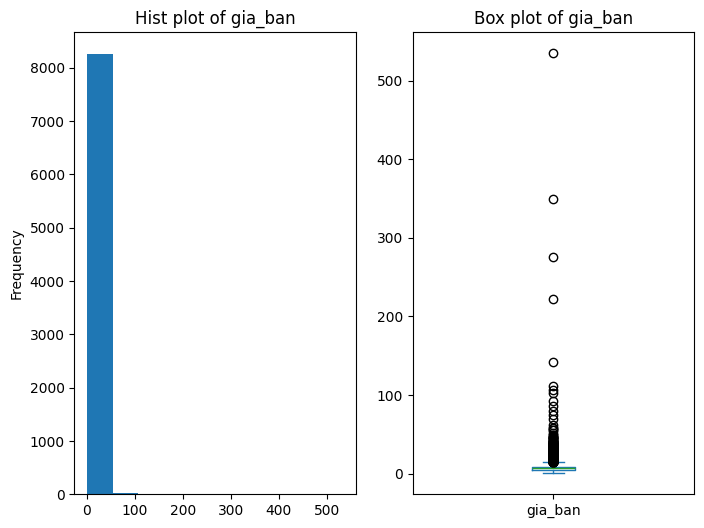

In [40]:
_analyzer.analyze_numeric_variable('gia_ban', df_output)

#### Bi-variate analysis

In [41]:
# Numeric input vs Output

In [42]:
df_num = df_input.select_dtypes(exclude='O')
df_num_out = pd.concat([df_num, df_output], axis=1)
df_num_out.corr()

,dien_tich,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,chieu_ngang,chieu_dai,gia_ban
dien_tich,1.000000,0.449141,0.299215,0.089664,0.033129,0.028665,0.693561
so_phong_ngu,0.449141,1.000000,0.679808,0.381277,0.023155,0.022643,0.349046
so_phong_ve_sinh,0.299215,0.679808,1.000000,0.479663,0.014863,0.012570,0.251863
tong_so_tang,0.089664,0.381277,0.479663,1.000000,0.002102,0.001468,0.149495
chieu_ngang,0.033129,0.023155,0.014863,0.002102,1.000000,0.989259,0.013473
chieu_dai,0.028665,0.022643,0.012570,0.001468,0.989259,1.000000,0.010444
gia_ban,0.693561,0.349046,0.251863,0.149495,0.013473,0.010444,1.000000


##### **Nhận xét:** Ta thấy diện tích có tương quan cao với giá bán --> nhà lớn thì giá cao. Bên cạnh đó, số phòng ngủ và số phòng vệ sinh cũng có ảnh hưởng nhẹ đến giá nhà.

In [43]:
# Categorical input vs Output

In [44]:
output_col = df_output.columns[0]
output_col

'gia_ban'

In [45]:
df_cat = df_input.select_dtypes('O')
df_temp = pd.concat([df_cat, df_output], axis=1)

                   sum_sq      df          F        PR(>F)
C(dia_chi)    5266.416951     2.0  26.757423  2.611173e-12
Residual    813853.935774  8270.0        NaN           NaN


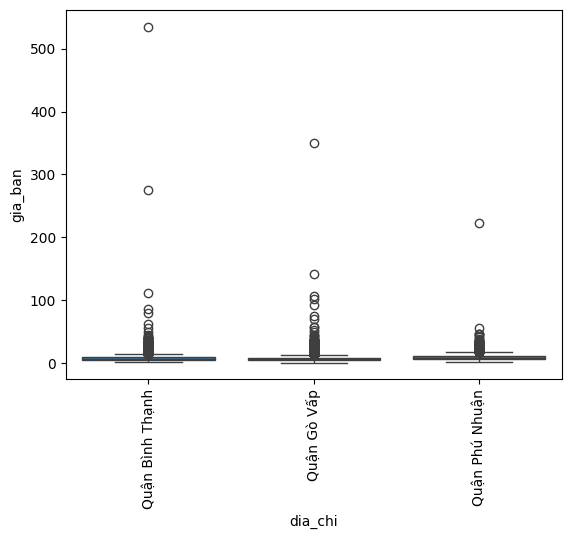

                     sum_sq      df           F         PR(>F)
C(loai_hinh)   98910.159632     4.0  283.871711  4.531756e-229
Residual      720210.193093  8268.0         NaN            NaN


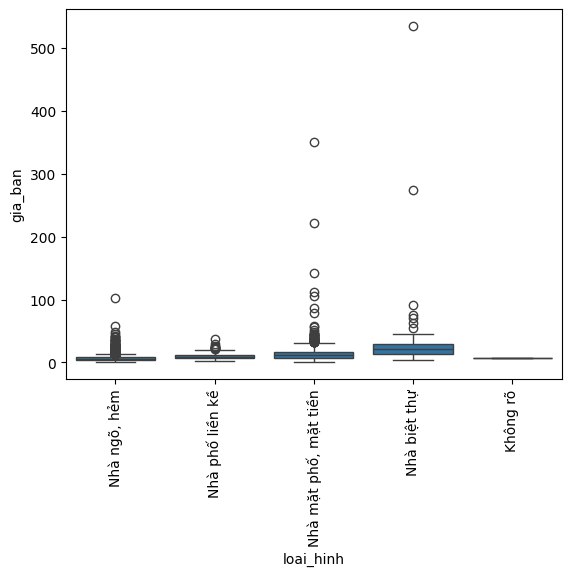

                           sum_sq      df         F    PR(>F)
C(giay_to_phap_ly)    1542.491677     5.0  3.119404  0.008134
Residual            817577.861048  8267.0       NaN       NaN


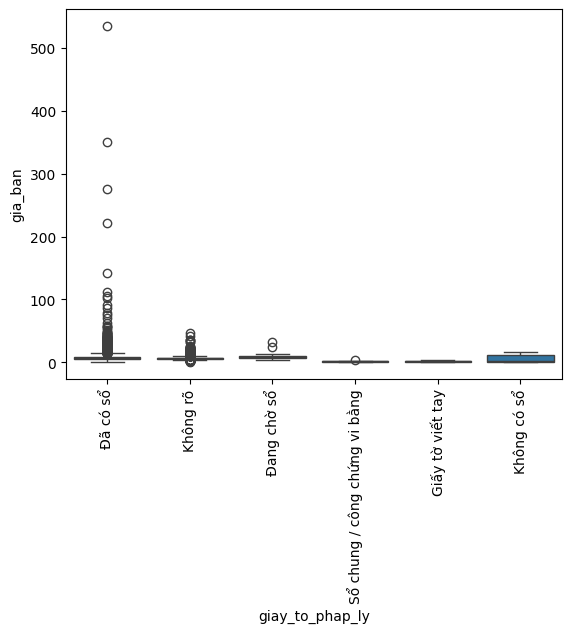

                               sum_sq      df         F    PR(>F)
C(tinh_trang_noi_that)     693.607208     4.0  1.751759  0.135629
Residual                818426.745517  8268.0       NaN       NaN


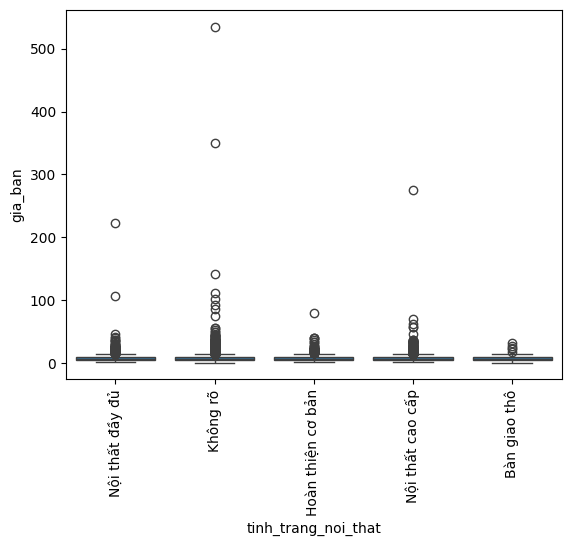

                    sum_sq      df         F    PR(>F)
C(dac_diem)    1430.672264     7.0  2.065839  0.043693
Residual     817689.680461  8265.0       NaN       NaN


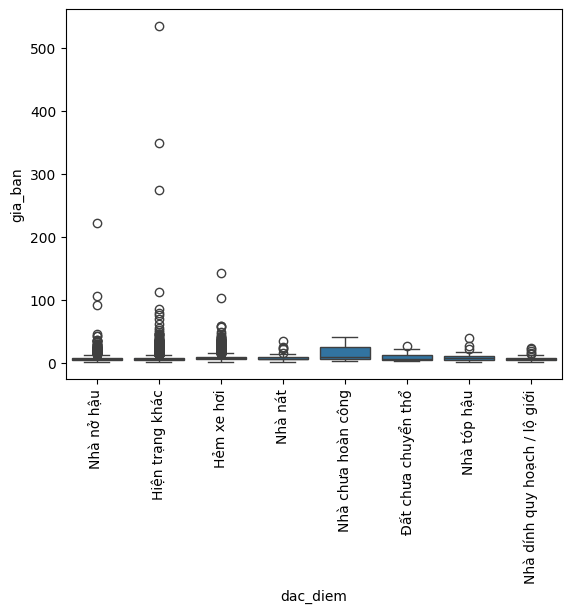

In [46]:
for col in cat_cols:
    _analyzer.analyze_continuous_vs_categories(output_col, col, df_temp)

In [47]:
# Categorical input vs Categorical input

In [48]:
unique_pair_var = _analyzer.create_unique_pair_variable(cat_cols)
unique_pair_var

[{'dia_chi', 'loai_hinh'},
 {'dia_chi', 'giay_to_phap_ly'},
 {'dia_chi', 'tinh_trang_noi_that'},
 {'dac_diem', 'dia_chi'},
 {'giay_to_phap_ly', 'loai_hinh'},
 {'loai_hinh', 'tinh_trang_noi_that'},
 {'dac_diem', 'loai_hinh'},
 {'giay_to_phap_ly', 'tinh_trang_noi_that'},
 {'dac_diem', 'giay_to_phap_ly'},
 {'dac_diem', 'tinh_trang_noi_that'}]

=====Analyze of dia_chi and loai_hinh=====
Reject H0 - Dependent


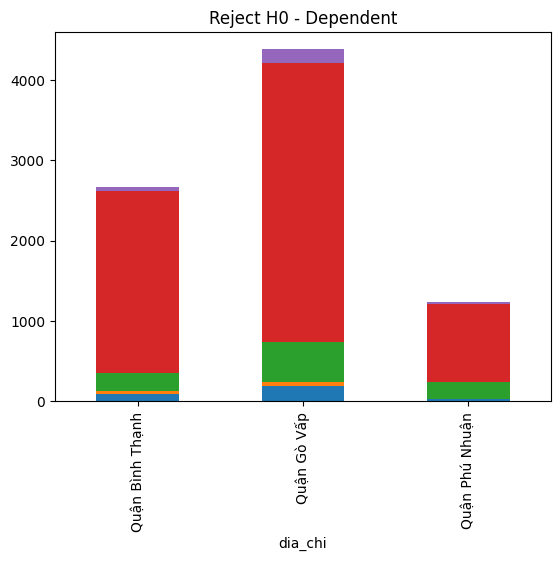

=====Analyze of giay_to_phap_ly and dia_chi=====
Fail to reject H0 - Independent


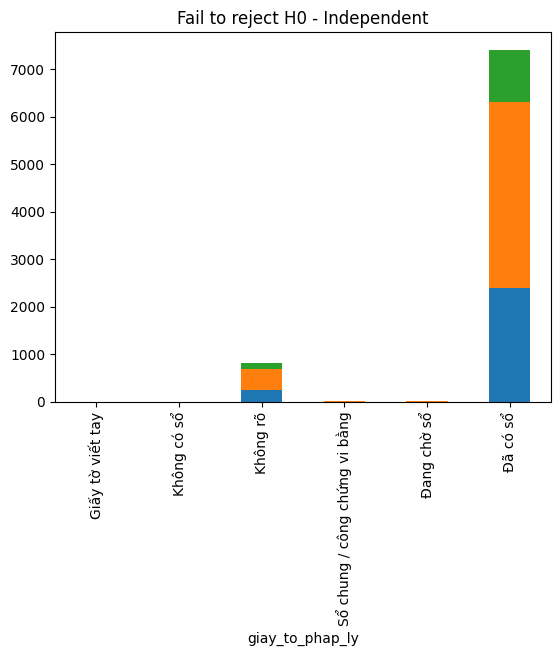

=====Analyze of tinh_trang_noi_that and dia_chi=====
Reject H0 - Dependent


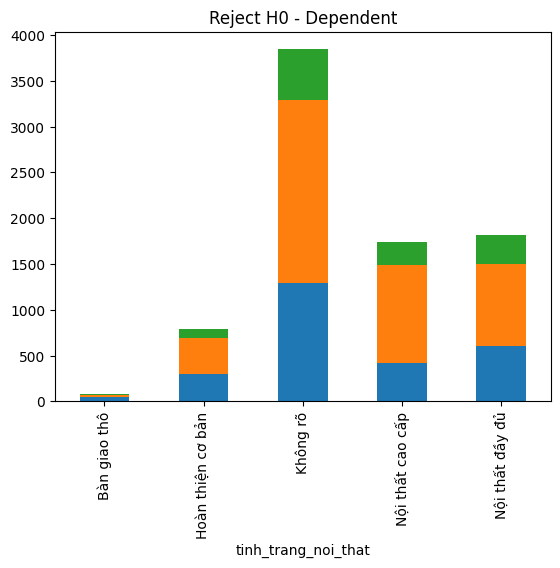

=====Analyze of dac_diem and dia_chi=====
Reject H0 - Dependent


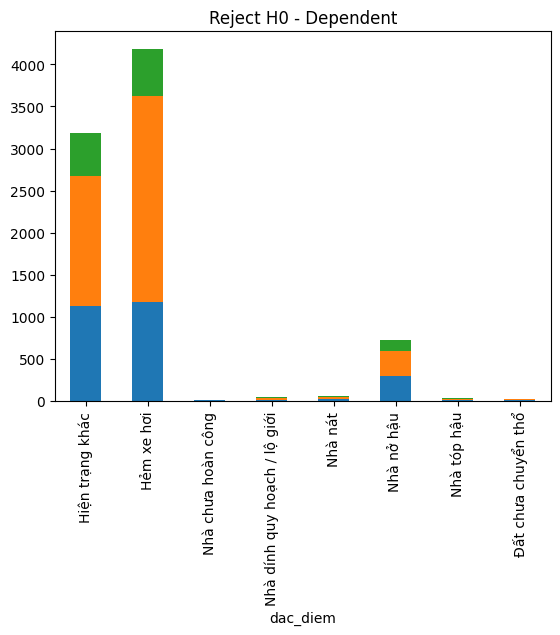

=====Analyze of giay_to_phap_ly and loai_hinh=====
Reject H0 - Dependent


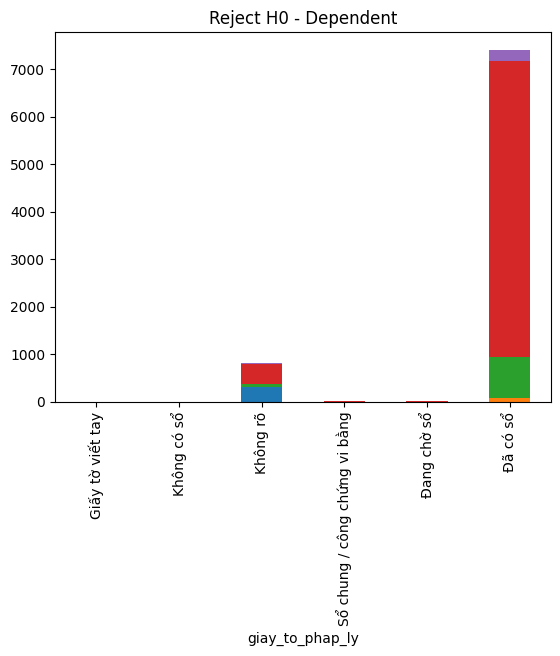

=====Analyze of tinh_trang_noi_that and loai_hinh=====
Reject H0 - Dependent


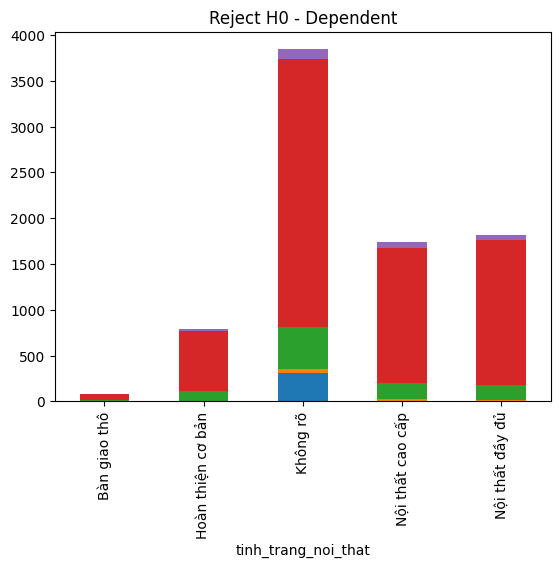

=====Analyze of dac_diem and loai_hinh=====
Reject H0 - Dependent


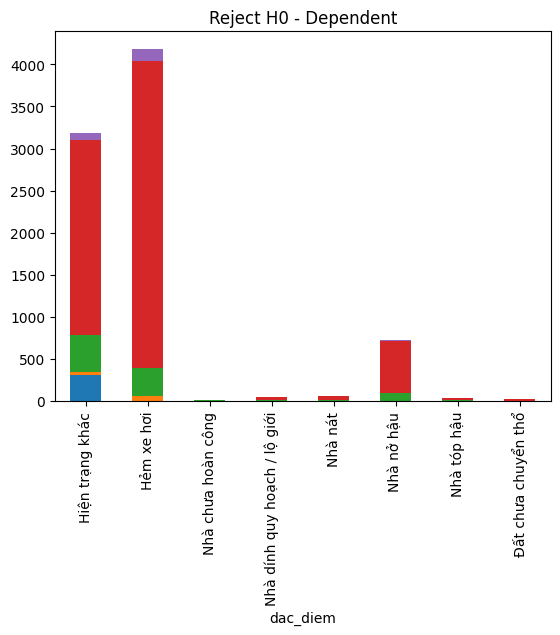

=====Analyze of giay_to_phap_ly and tinh_trang_noi_that=====
Reject H0 - Dependent


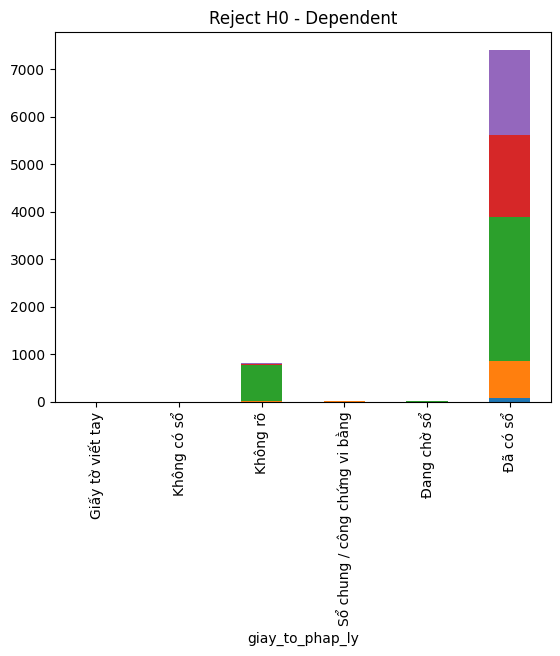

=====Analyze of giay_to_phap_ly and dac_diem=====
Reject H0 - Dependent


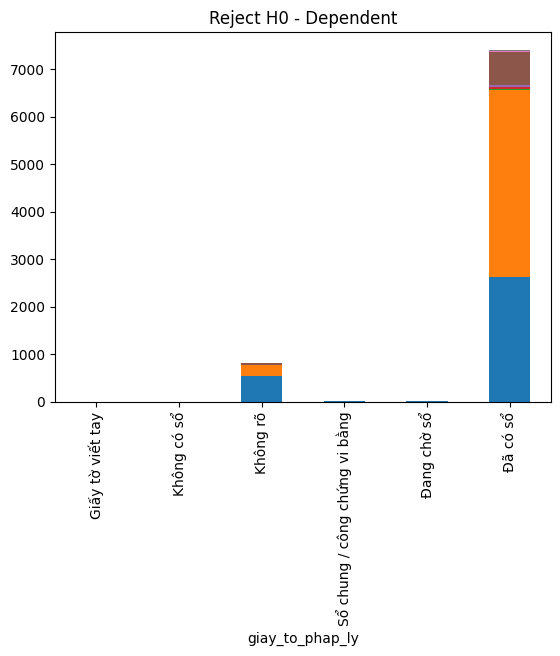

=====Analyze of dac_diem and tinh_trang_noi_that=====
Reject H0 - Dependent


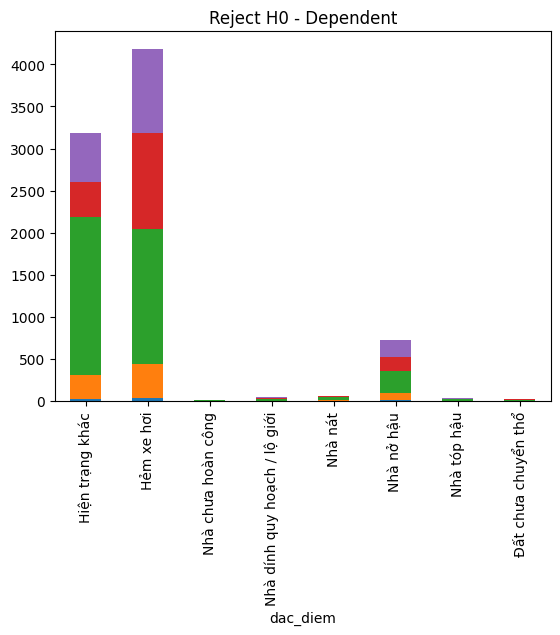

In [49]:
result = []
for var1, var2 in unique_pair_var:
    r = _analyzer.analyze_category_vs_category(var1, var2, df_input)
    result.append(r)

In [50]:
pd.DataFrame(result)

,var1,var2,result
0,dia_chi,loai_hinh,Reject H0 - Dependent
1,giay_to_phap_ly,dia_chi,Fail to reject H0 - Independent
2,tinh_trang_noi_that,dia_chi,Reject H0 - Dependent
3,dac_diem,dia_chi,Reject H0 - Dependent
4,giay_to_phap_ly,loai_hinh,Reject H0 - Dependent
5,tinh_trang_noi_that,loai_hinh,Reject H0 - Dependent
6,dac_diem,loai_hinh,Reject H0 - Dependent
7,giay_to_phap_ly,tinh_trang_noi_that,Reject H0 - Dependent
8,giay_to_phap_ly,dac_diem,Reject H0 - Dependent
9,dac_diem,tinh_trang_noi_that,Reject H0 - Dependent


In [51]:
# Numeric input vs Categorical input

In [52]:
num_cols

Index(['dien_tich', 'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'chieu_ngang', 'chieu_dai'],
      dtype='object')

In [53]:
cat_cols

Index(['dia_chi', 'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
       'dac_diem'],
      dtype='object')

In [54]:
df_temp = pd.concat([df_num, df_cat], axis=1)

dien_tich - dia_chi
                  sum_sq      df          F        PR(>F)
C(dia_chi)  6.916415e+04     2.0  21.644077  4.213204e-10
Residual    1.321349e+07  8270.0        NaN           NaN


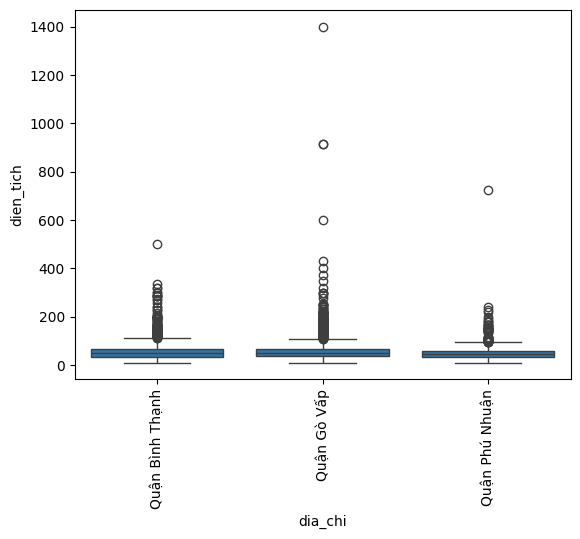

dien_tich - loai_hinh
                    sum_sq      df           F         PR(>F)
C(loai_hinh)  1.524843e+06     4.0  268.064386  5.588145e-217
Residual      1.175781e+07  8268.0         NaN            NaN


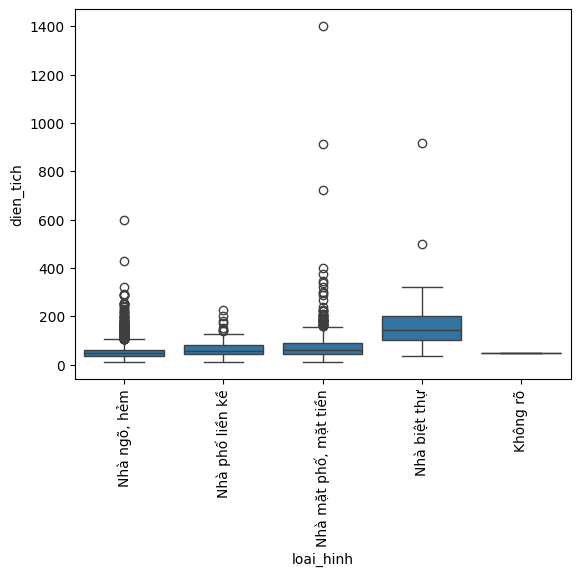

dien_tich - giay_to_phap_ly
                          sum_sq      df         F    PR(>F)
C(giay_to_phap_ly)  3.605135e+04     5.0  4.499819  0.000426
Residual            1.324660e+07  8267.0       NaN       NaN


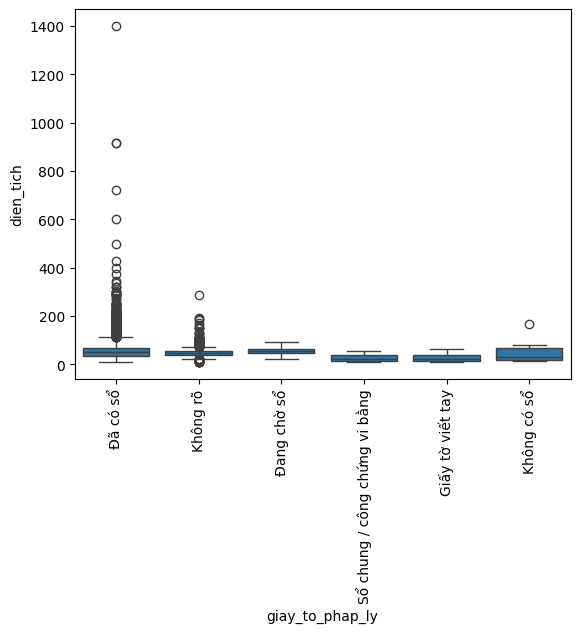

dien_tich - tinh_trang_noi_that
                              sum_sq      df         F    PR(>F)
C(tinh_trang_noi_that)  4.405314e+04     4.0  6.878209  0.000016
Residual                1.323860e+07  8268.0       NaN       NaN


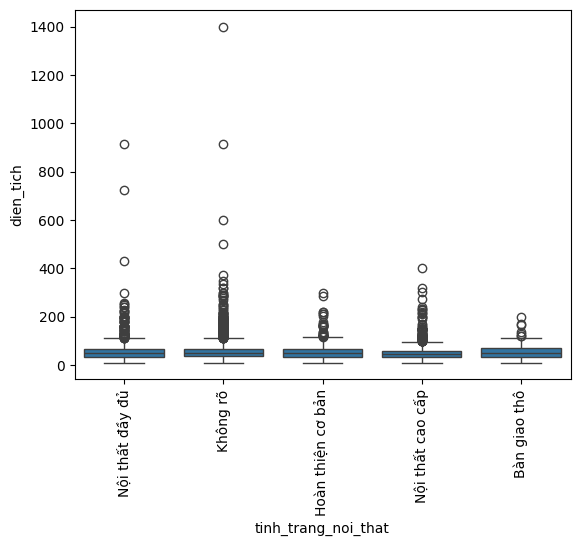

dien_tich - dac_diem
                   sum_sq      df         F        PR(>F)
C(dac_diem)  1.881032e+05     7.0  16.96096  2.078691e-22
Residual     1.309455e+07  8265.0       NaN           NaN


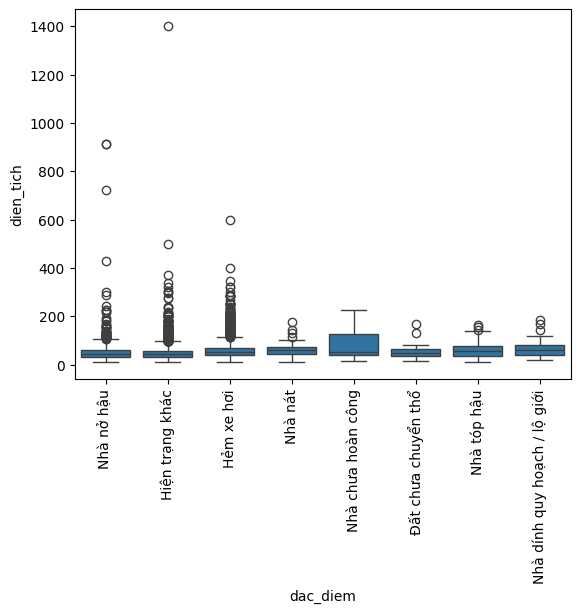

so_phong_ngu - dia_chi
                  sum_sq      df          F    PR(>F)
C(dia_chi)     83.670622     2.0  13.199108  0.000002
Residual    26212.227118  8270.0        NaN       NaN


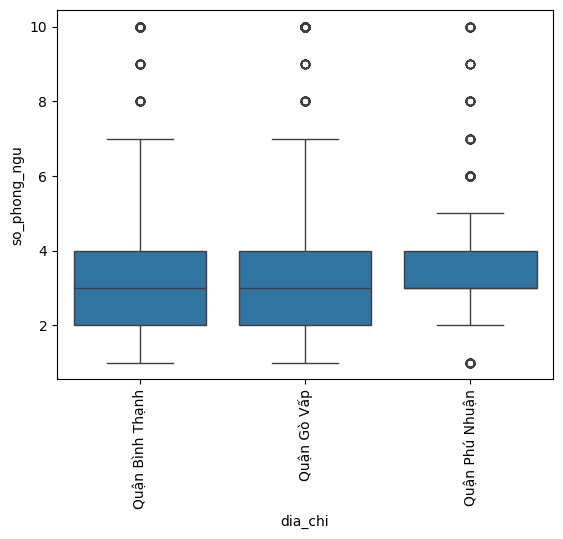

so_phong_ngu - loai_hinh
                    sum_sq      df          F        PR(>F)
C(loai_hinh)    953.423308     4.0  77.763755  7.472937e-65
Residual      25342.474432  8268.0        NaN           NaN


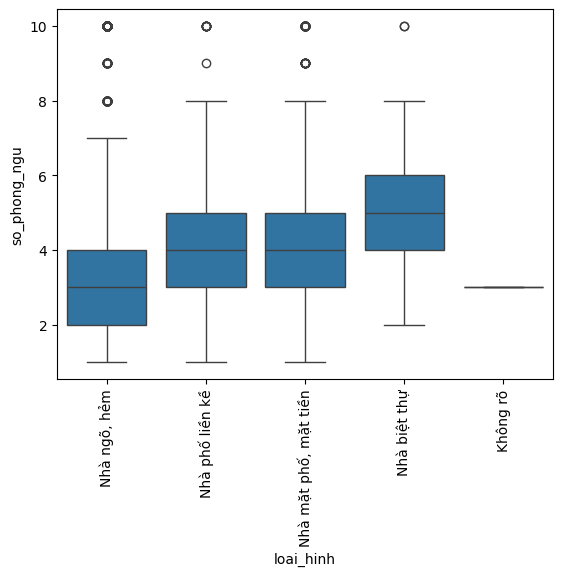

so_phong_ngu - giay_to_phap_ly
                          sum_sq      df         F    PR(>F)
C(giay_to_phap_ly)     96.754379     5.0  6.106066  0.000012
Residual            26199.143361  8267.0       NaN       NaN


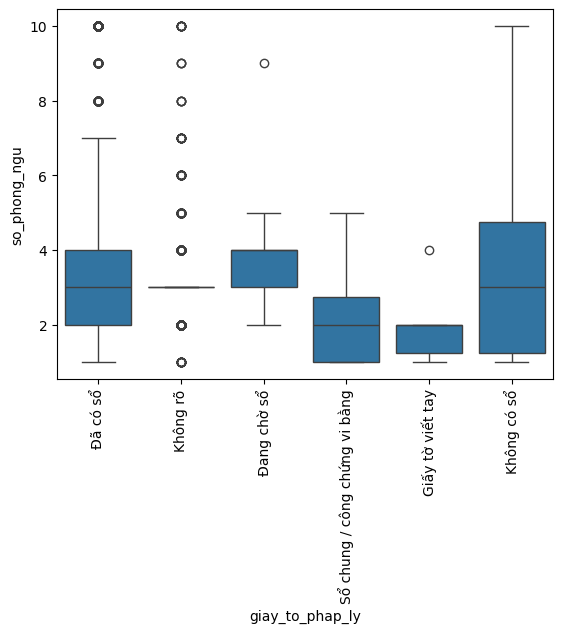

so_phong_ngu - tinh_trang_noi_that
                              sum_sq      df          F        PR(>F)
C(tinh_trang_noi_that)    225.202653     4.0  17.855062  1.315354e-14
Residual                26070.695086  8268.0        NaN           NaN


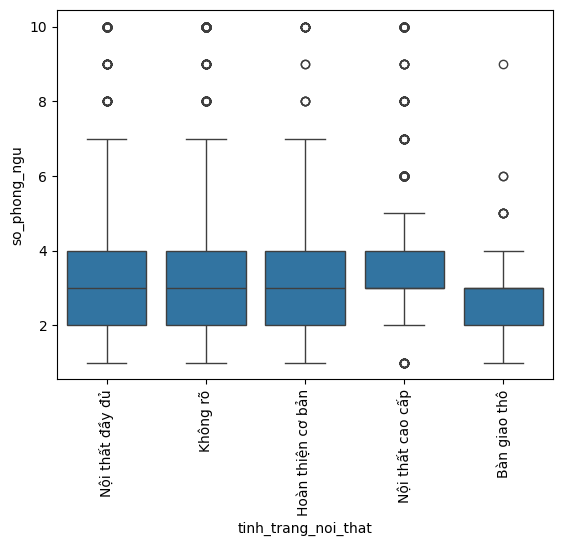

so_phong_ngu - dac_diem
                   sum_sq      df          F        PR(>F)
C(dac_diem)    588.144205     7.0  27.012483  6.423235e-37
Residual     25707.753535  8265.0        NaN           NaN


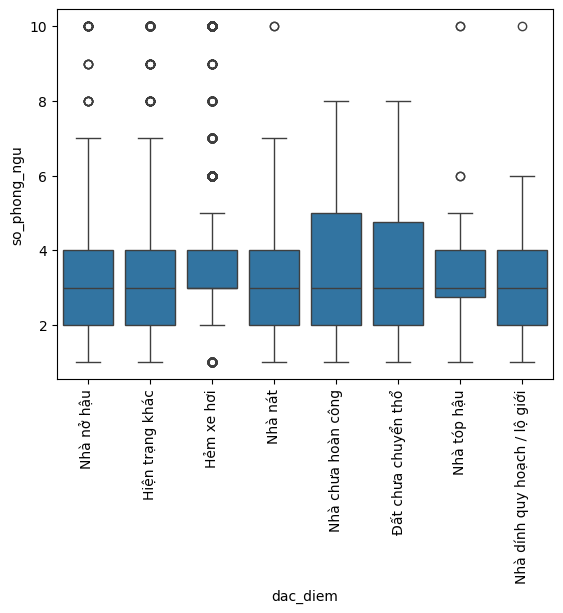

so_phong_ve_sinh - dia_chi
                  sum_sq      df          F        PR(>F)
C(dia_chi)    104.507446     2.0  34.254433  1.530275e-15
Residual    12615.543564  8270.0        NaN           NaN


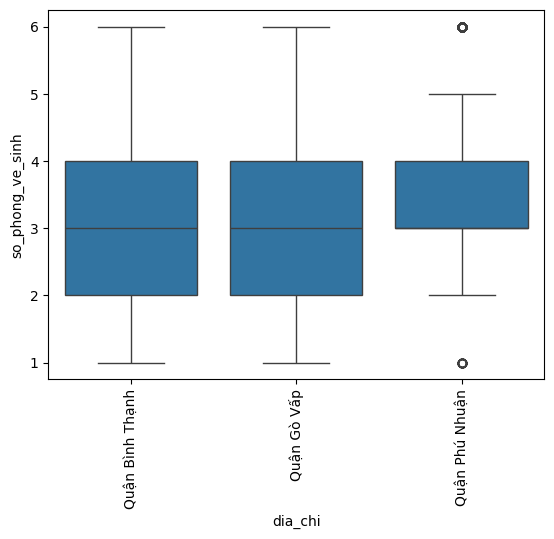

so_phong_ve_sinh - loai_hinh
                    sum_sq      df          F        PR(>F)
C(loai_hinh)    487.782880     4.0  82.425205  9.996013e-69
Residual      12232.268129  8268.0        NaN           NaN


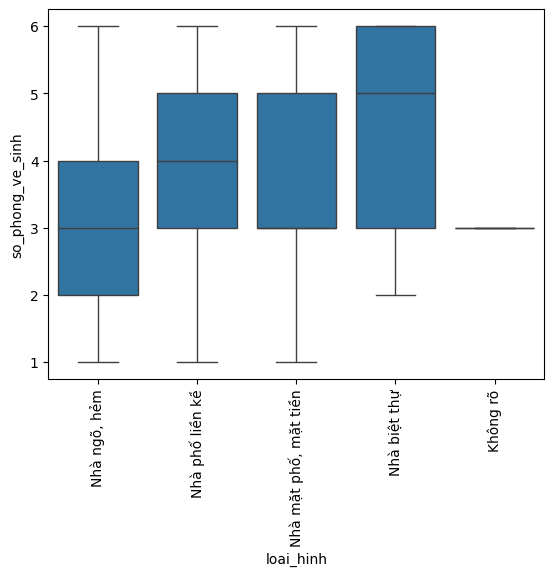

so_phong_ve_sinh - giay_to_phap_ly
                          sum_sq      df         F        PR(>F)
C(giay_to_phap_ly)     64.741347     5.0  8.458374  5.386978e-08
Residual            12655.309663  8267.0       NaN           NaN


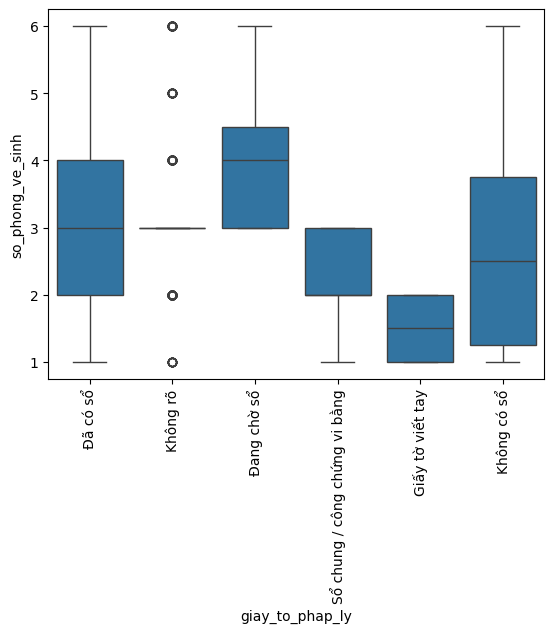

so_phong_ve_sinh - tinh_trang_noi_that
                              sum_sq      df          F        PR(>F)
C(tinh_trang_noi_that)    398.172831     4.0  66.793652  1.039268e-55
Residual                12321.878179  8268.0        NaN           NaN


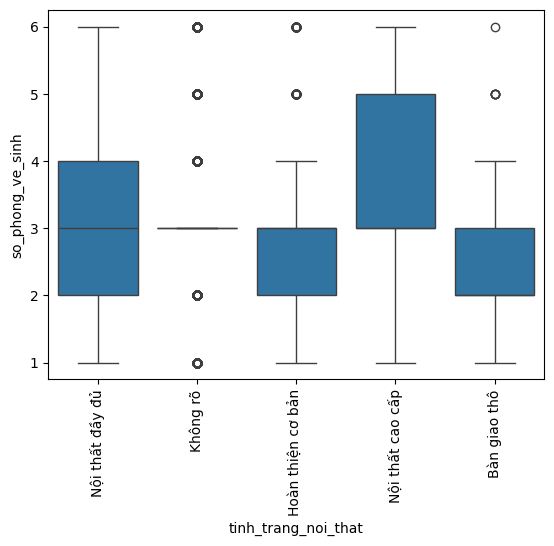

so_phong_ve_sinh - dac_diem
                   sum_sq      df          F        PR(>F)
C(dac_diem)    398.572457     7.0  38.193484  4.280928e-53
Residual     12321.478552  8265.0        NaN           NaN


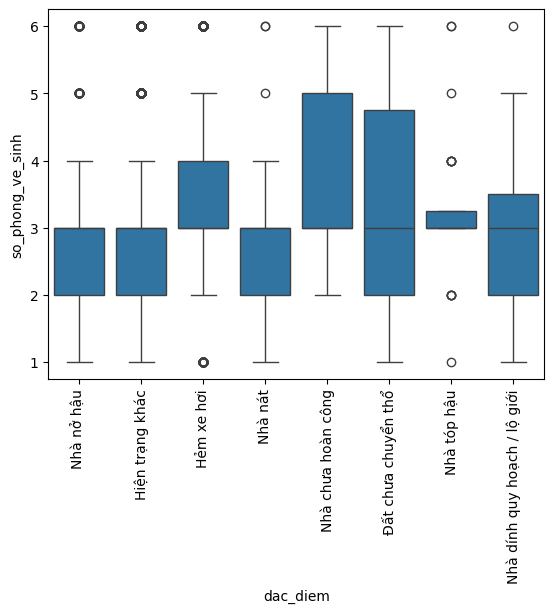

tong_so_tang - dia_chi
                  sum_sq      df          F        PR(>F)
C(dia_chi)    190.692882     2.0  56.900561  2.863395e-25
Residual    13857.773212  8270.0        NaN           NaN


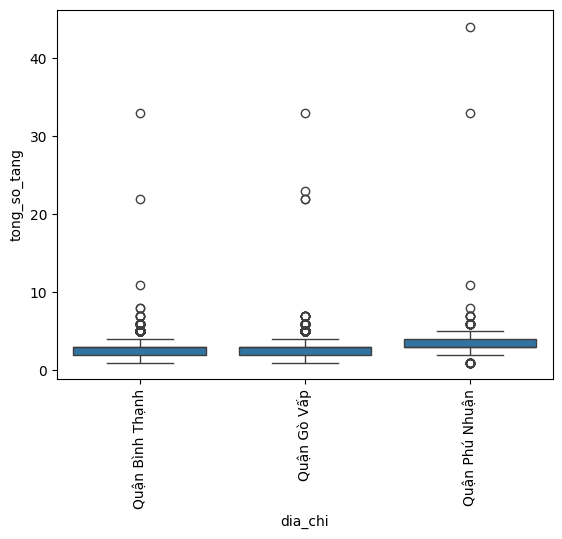

tong_so_tang - loai_hinh
                    sum_sq      df          F        PR(>F)
C(loai_hinh)    160.177947     4.0  23.839354  1.242681e-19
Residual      13888.288148  8268.0        NaN           NaN


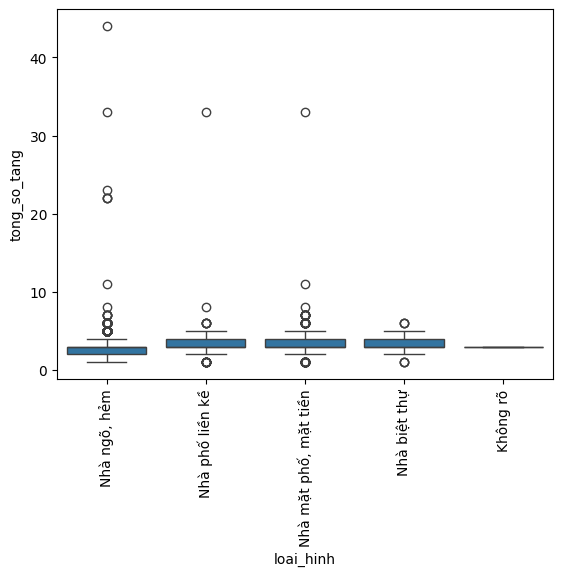

tong_so_tang - giay_to_phap_ly
                          sum_sq      df         F    PR(>F)
C(giay_to_phap_ly)     20.722818     5.0  2.442525  0.032074
Residual            14027.743276  8267.0       NaN       NaN


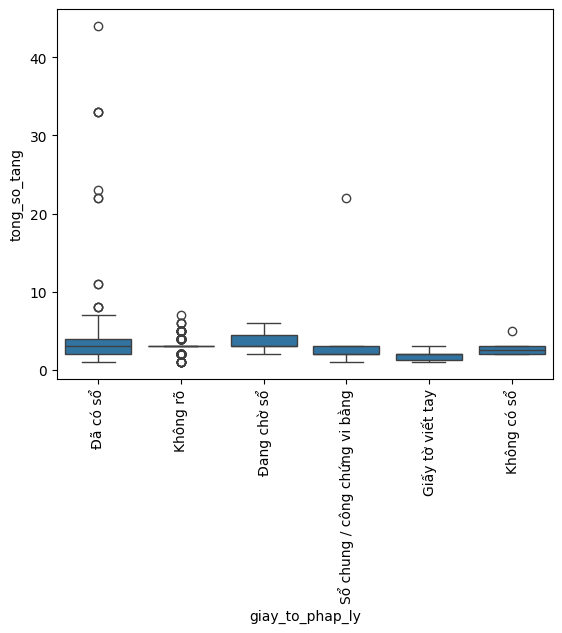

tong_so_tang - tinh_trang_noi_that
                              sum_sq      df          F        PR(>F)
C(tinh_trang_noi_that)    230.870025     4.0  34.536278  1.225959e-28
Residual                13817.596070  8268.0        NaN           NaN


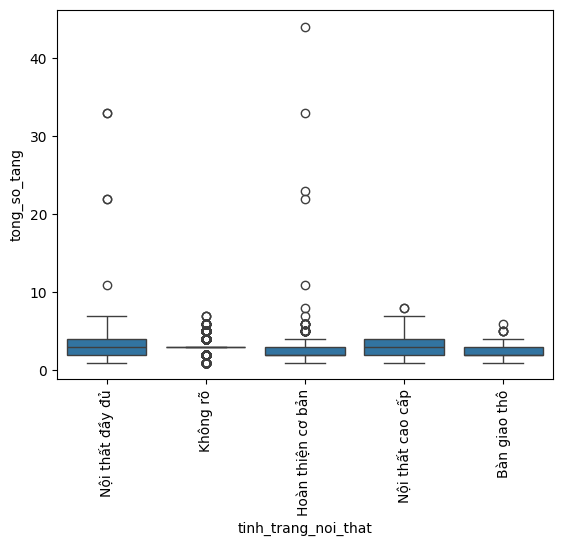

tong_so_tang - dac_diem
                   sum_sq      df          F        PR(>F)
C(dac_diem)    127.885190     7.0  10.846952  1.080762e-13
Residual     13920.580904  8265.0        NaN           NaN


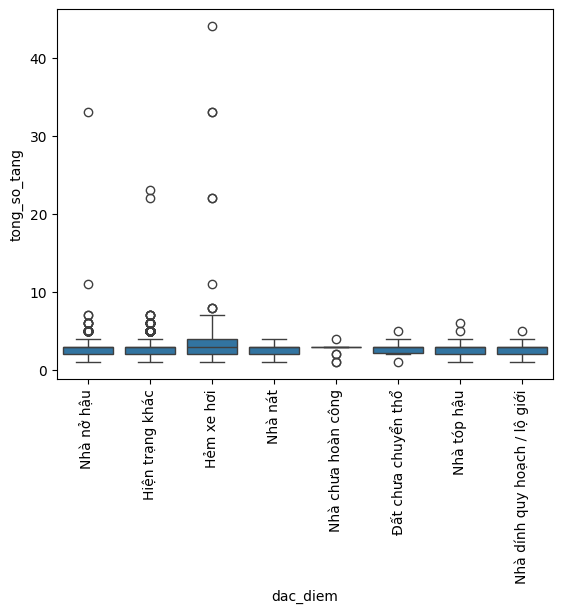

chieu_ngang - dia_chi
                  sum_sq      df         F   PR(>F)
C(dia_chi)  4.081181e+03     2.0  1.035147  0.35522
Residual    1.630270e+07  8270.0       NaN      NaN


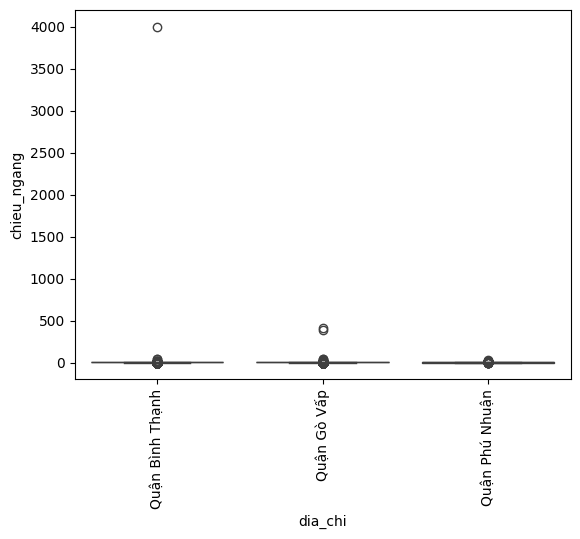

chieu_ngang - loai_hinh
                    sum_sq      df         F    PR(>F)
C(loai_hinh)  1.175982e+03     4.0  0.149075  0.963468
Residual      1.630560e+07  8268.0       NaN       NaN


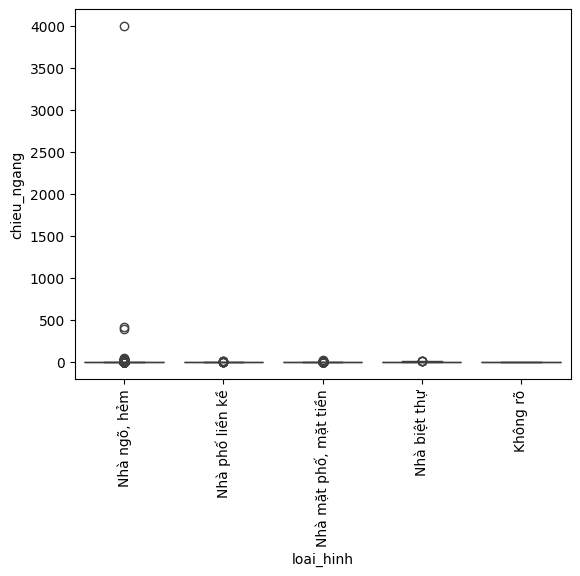

chieu_ngang - giay_to_phap_ly
                          sum_sq      df         F    PR(>F)
C(giay_to_phap_ly)  6.000992e+02     5.0  0.060848  0.997562
Residual            1.630618e+07  8267.0       NaN       NaN


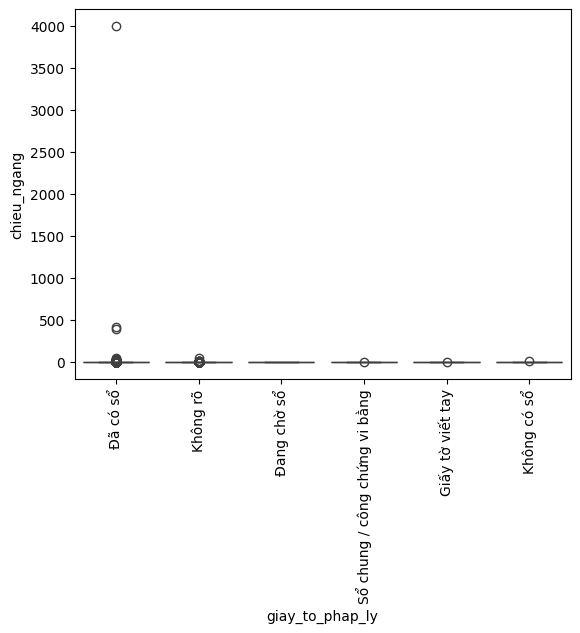

chieu_ngang - tinh_trang_noi_that
                              sum_sq      df          F        PR(>F)
C(tinh_trang_noi_that)  1.941930e+05     4.0  24.912019  1.556042e-20
Residual                1.611259e+07  8268.0        NaN           NaN


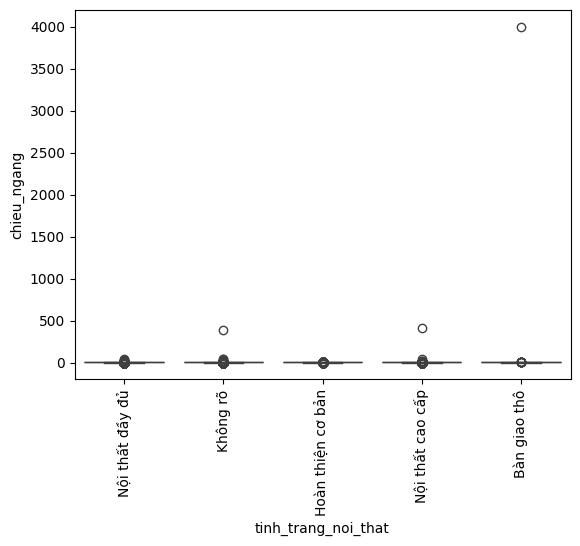

chieu_ngang - dac_diem
                   sum_sq      df         F    PR(>F)
C(dac_diem)  2.604913e+03     7.0  0.188642  0.987875
Residual     1.630417e+07  8265.0       NaN       NaN


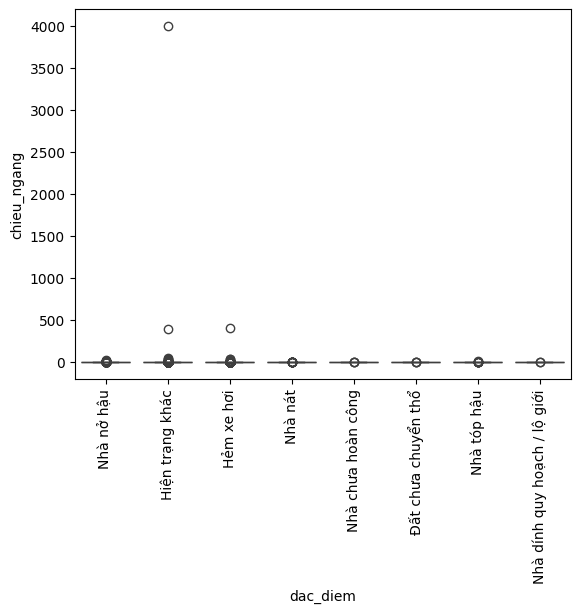

chieu_dai - dia_chi
                  sum_sq      df         F    PR(>F)
C(dia_chi)  1.410798e+05     2.0  1.013907  0.362844
Residual    5.753635e+08  8270.0       NaN       NaN


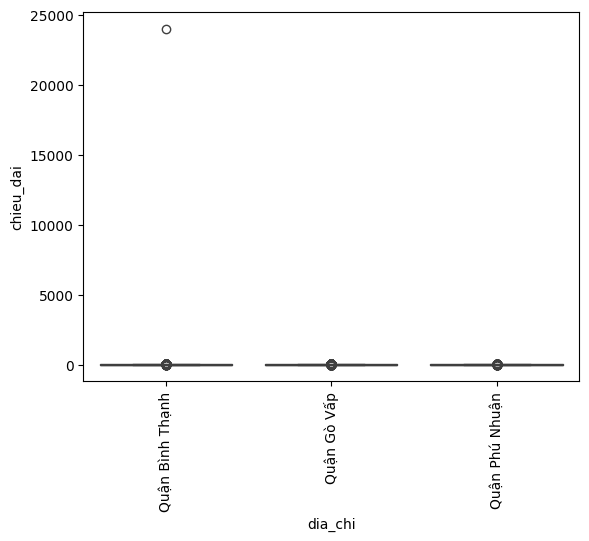

chieu_dai - loai_hinh
                    sum_sq      df         F    PR(>F)
C(loai_hinh)  5.010546e+03     4.0  0.017996  0.999367
Residual      5.754995e+08  8268.0       NaN       NaN


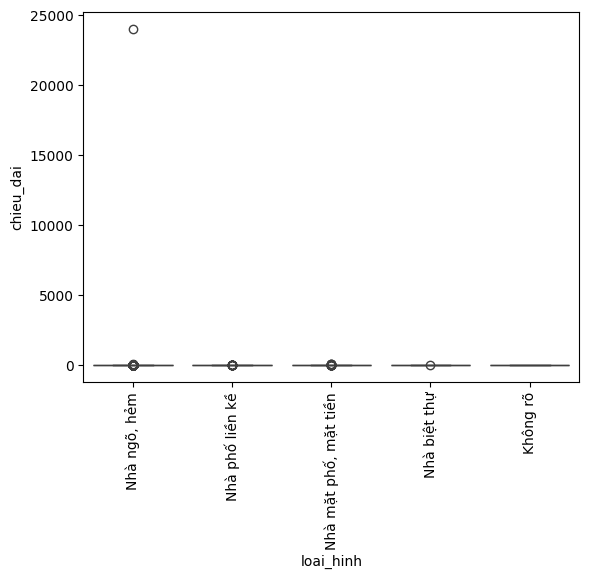

chieu_dai - giay_to_phap_ly
                          sum_sq      df         F    PR(>F)
C(giay_to_phap_ly)  1.087075e+04     5.0  0.031232  0.999515
Residual            5.754937e+08  8267.0       NaN       NaN


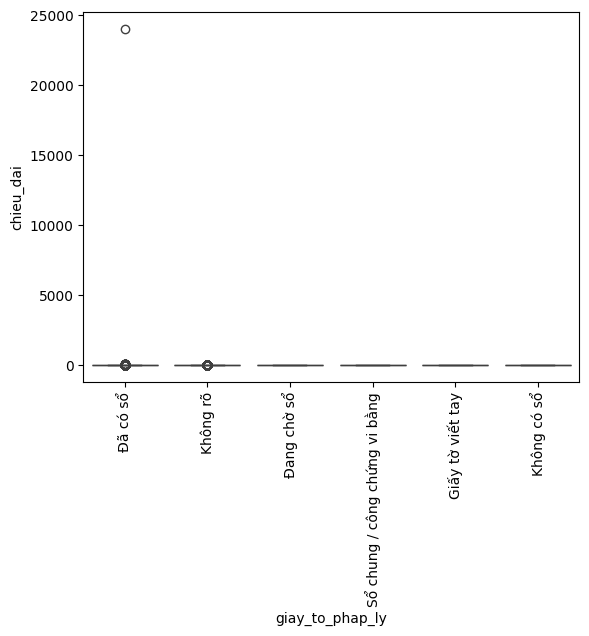

chieu_dai - tinh_trang_noi_that
                              sum_sq      df          F        PR(>F)
C(tinh_trang_noi_that)  6.953567e+06     4.0  25.280096  7.626372e-21
Residual                5.685510e+08  8268.0        NaN           NaN


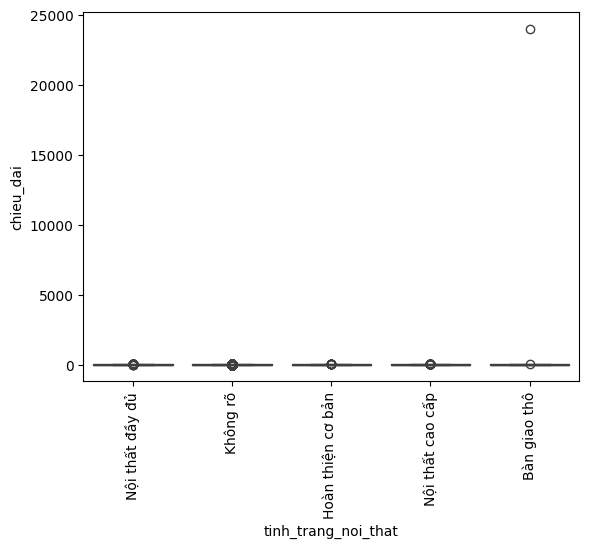

chieu_dai - dac_diem
                   sum_sq      df        F    PR(>F)
C(dac_diem)  8.577810e+04     7.0  0.17601  0.990163
Residual     5.754188e+08  8265.0      NaN       NaN


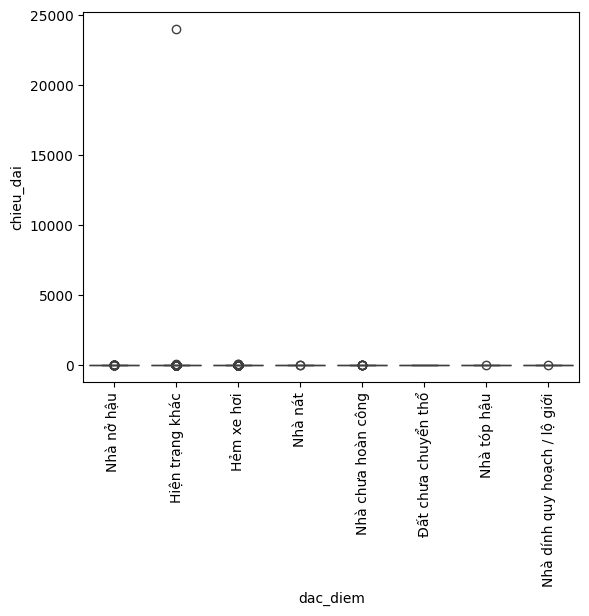

In [55]:
for num_col in num_cols:
    for cat_col in cat_cols:
        print(num_col, '-', cat_col)
        _analyzer.analyze_continuous_vs_categories(num_col, cat_col, df_temp)

### Feature Engineering

#### Encode categorical data into numeric data

In [56]:
cat_cols

Index(['dia_chi', 'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
       'dac_diem'],
      dtype='object')

In [57]:
# Encode for dia_chi with OneHotEncoder to avoid bias

In [58]:
from sklearn.preprocessing import OneHotEncoder

In [59]:
df[cat_cols].head()

,dia_chi,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,dac_diem
0,Quận Bình Thạnh,"Nhà ngõ, hẻm",Đã có sổ,Nội thất đầy đủ,Nhà nở hậu
1,Quận Bình Thạnh,"Nhà ngõ, hẻm",Không rõ,Không rõ,Hiện trạng khác
2,Quận Bình Thạnh,"Nhà ngõ, hẻm",Đã có sổ,Hoàn thiện cơ bản,Hẻm xe hơi
3,Quận Bình Thạnh,"Nhà ngõ, hẻm",Đã có sổ,Không rõ,Hiện trạng khác
4,Quận Bình Thạnh,"Nhà ngõ, hẻm",Đã có sổ,Không rõ,Hiện trạng khác


In [60]:
for col in cat_cols:
    if col == 'dia_chi':
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded_data = encoder.fit_transform(df[[col]])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.categories_[0][1:]).add_prefix('e_')
        df = pd.concat([df, encoded_df], axis=1)

In [61]:
df.drop(columns=['dia_chi'], inplace=True)

In [62]:
df.head()

,gia_ban,dien_tich,loai_hinh,giay_to_phap_ly,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,dac_diem,chieu_ngang,chieu_dai,e_Quận Gò Vấp,e_Quận Phú Nhuận
0,3.85,36.0,"Nhà ngõ, hẻm",Đã có sổ,2.0,2.0,2.0,Nội thất đầy đủ,Nhà nở hậu,4.5,8.0,0.0,0.0
1,9.79,62.0,"Nhà ngõ, hẻm",Không rõ,4.0,3.0,3.0,Không rõ,Hiện trạng khác,4.0,12.0,0.0,0.0
2,7.20,54.0,"Nhà ngõ, hẻm",Đã có sổ,3.0,2.0,2.0,Hoàn thiện cơ bản,Hẻm xe hơi,7.0,7.7,0.0,0.0
3,8.50,83.0,"Nhà ngõ, hẻm",Đã có sổ,3.0,3.0,3.0,Không rõ,Hiện trạng khác,7.5,11.5,0.0,0.0
4,2.85,18.0,"Nhà ngõ, hẻm",Đã có sổ,2.0,1.0,3.0,Không rõ,Hiện trạng khác,3.0,6.0,0.0,0.0


In [63]:
# Encode giay_to_phap_ly

In [64]:
mapping = {'Không có sổ': 0,
           'Không rõ': 1,
           'Giấy tờ viết tay': 2,
           'Đang chờ sổ': 3,
           'Sổ chung / công chứng vi bằng': 4,
           'Đã có sổ': 5}

In [65]:
df["giay_to_phap_ly"] = df["giay_to_phap_ly"].map(mapping)

In [66]:
# Encode tinh_trang_noi_that

In [67]:
mapping = {'Bàn giao thô': 0,
           'Không rõ': 1,
           'Hoàn thiện cơ bản': 2,
           'Nội thất đầy đủ': 3,
           'Nội thất cao cấp': 4}

In [68]:
df["tinh_trang_noi_that"] = df["tinh_trang_noi_that"].map(mapping)

In [69]:
# Encode loai_hinh

In [70]:
mapping = {'Nhà ngõ, hẻm': 0,
           'Không rõ': 1,
           'Nhà phố liền kề': 2,
           'Nhà mặt phố, mặt tiền': 3,
           'Nhà biệt thự': 4}

In [71]:
df["loai_hinh"] = df["loai_hinh"].map(mapping)

In [72]:
# Encode dac_diem

In [73]:
mapping = {'Đất chưa chuyển thổ': 0,
           'Nhà nát': 1,
           'Hiện trạng khác': 2,
           'Nhà dính quy hoạch / lộ giới': 3,
           'Nhà chưa hoàn công': 4,
           'Nhà tóp hậu': 5,
           'Nhà nở hậu': 6,
           'Hẻm xe hơi': 7}

In [74]:
df["dac_diem"] = df["dac_diem"].map(mapping)

In [75]:
df.head()

,gia_ban,dien_tich,loai_hinh,giay_to_phap_ly,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,dac_diem,chieu_ngang,chieu_dai,e_Quận Gò Vấp,e_Quận Phú Nhuận
0,3.85,36.0,0,5,2.0,2.0,2.0,3,6,4.5,8.0,0.0,0.0
1,9.79,62.0,0,1,4.0,3.0,3.0,1,2,4.0,12.0,0.0,0.0
2,7.20,54.0,0,5,3.0,2.0,2.0,2,7,7.0,7.7,0.0,0.0
3,8.50,83.0,0,5,3.0,3.0,3.0,1,2,7.5,11.5,0.0,0.0
4,2.85,18.0,0,5,2.0,1.0,3.0,1,2,3.0,6.0,0.0,0.0


In [76]:
df.to_csv("/content/gdrive/MyDrive/DL07_K311_HuynhLeXuanAnh_DangDucDuy_NguyenThiTuyetVan/Project 1/data/clean_data.csv", index=False)